# Evaluación de modelos de clasificación de imágenes:

bibliotecas y funciones útiles

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
import time
import torch
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, roc_curve, auc, log_loss
from sklearn.preprocessing import label_binarize
from utils.funciones_minio import bajar_minio,crear_cliente_minio,buscar_todos_los_archivos
from sklearn.metrics import accuracy_score, f1_score
import random
import io
import wandb
import os
import tensorflow as tf
clases = ["Salón","Dormitorio","Cocina","Banyo"]


In [3]:
def visualizar_matriz_confusion(y_test, y_pred, nombre_modelo,clases):
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=clases, yticklabels=clases,
                annot_kws={"size": 14, "weight": "bold"}) 
    
    plt.title(f'Matriz de Confusión - {nombre_modelo}', fontsize=16, pad=20, weight='bold')
    plt.ylabel('Etiqueta Real', fontsize=12, weight='bold')
    plt.xlabel('Predicción', fontsize=12, weight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [4]:
def visualizar_curva_roc(y_test, y_score, nombre_modelo, clases):
    y_test_bin = label_binarize(y_test, classes=range(len(clases)))
    
    plt.figure(figsize=(9, 7))
    sns.set_style("whitegrid")
    colores = ['#e63946', '#2a9d8f', '#e9c46a', '#264653']
    
    for i, color in enumerate(colores):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{clases[i]} (AUC = {roc_auc:.3f})')
        
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Azar (AUC = 0.500)')
    plt.xlim([-0.02, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)', weight='bold')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)', weight='bold')
    plt.title(f'Curvas ROC - {nombre_modelo}', fontsize=16, pad=20, weight='bold')
    plt.legend(loc="lower right", frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()

In [5]:
def evaluar_log_loss(y_test, y_score, nombre_modelo):
    if "SVC" in nombre_modelo or "Support Vector" in nombre_modelo:
        print(f" {nombre_modelo} usa fronteras de decisión (distancias), no probabilidades. Log Loss no aplicable.")
        return None
        
    valor_log_loss = log_loss(y_test, y_score)
    print(f" Log Loss para {nombre_modelo}: {valor_log_loss:.4f}")
    return valor_log_loss

In [6]:
def evaluar_f1_score(y_test, y_pred, nombre_modelo):
    """
    Calcula e imprime el F1-Score (Macro) para cualquier modelo.
    Requiere las clases finales predichas (y_pred), no las probabilidades.
    """
    valor_f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f" F1-Score (Macro) para {nombre_modelo}: {valor_f1:.4f}")
    
    return valor_f1

In [7]:
def obtener_predicciones(modelo, X_test):
    """
    Habla con cualquier modelo y extrae de forma segura sus predicciones.
    Devuelve:
      - y_pred: Array 1D con las clases predichas (ej: [2, 0, 1, 3...])
      - y_score: Array 2D con las probabilidades o distancias.
    """
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)
    elif hasattr(modelo, "decision_function"):
        y_score = modelo.decision_function(X_test)
    else:
        try:
            y_score = modelo.predict(X_test, verbose=0)
        except TypeError:
            y_score = modelo.predict(X_test) 

    
    if hasattr(modelo, "predict_proba") or hasattr(modelo, "decision_function"):
        y_pred = modelo.predict(X_test)
    else:
        y_pred = np.argmax(y_score, axis=1)
        
    return y_pred, y_score

In [8]:
def preparar_dataset(df:pd.DataFrame):
    df = df[df["clase"] != "Comedor"]
    X = np.stack(df['embedding'].values)
    codificador = LabelEncoder()
    y = codificador.fit_transform(df['clase'])  
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)
    print(f"Formato datos de train: {X_train.shape}")
    print(f"Formato datos de test: {X_test.shape}")
    return X_train,X_test,y_train,y_test

In [9]:
from sklearn.decomposition import PCA
def preparar_dataset_mlp(df: pd.DataFrame):
    """
    Prepara el dataset específicamente para el modelo MLP (Keras),
    replicando el recorte al 30% y aplicando el PCA de 512 componentes.
    """
    df = df[df["clase"] != "Comedor"]
    X = np.stack(df['embedding'].values)
    
    codificador = LabelEncoder()
    y = codificador.fit_transform(df['clase'])  
    
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.3, random_state=101, stratify=y
    )
    
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )
    
    pca = PCA(n_components=512, random_state=42)
    pca.fit(X_train)
    
    X_test_pca = pca.transform(X_test)
    
    print(f" Formato datos de test (Original): {X_test.shape}")
    print(f" Formato datos de test (PCA - Listo para Keras): {X_test_pca.shape}")
    
    return X_test_pca, y_test

Carga de datos y preparación del dataset

In [12]:
cliente = crear_cliente_minio()
ruta_ml = "dataset_ml"
fichero = "embeddings_imagenes.parquet"
df = bajar_minio(cliente, ruta_ml, fichero)
X_train,X_test,y_train,y_test = preparar_dataset(df)

Formato datos de train: (135380, 2048)
Formato datos de test: (33845, 2048)


In [19]:
class PyTorchWrapper:
    """Engaña a las funciones de gráficas para que traten a PyTorch como si fuera Keras"""
    def __init__(self, modelo):
        self.modelo = modelo
        self.modelo.eval()
    
    def predict(self, X, verbose=0):
        with torch.no_grad():
            tensor_X = torch.tensor(X.astype(np.float32))
            return self.modelo(tensor_X).numpy()
            
    # Le ponemos este nombre para que las gráficas lo reconozcan bonito
    @property
    def __class__(self):
        class _Proxy:
            __name__ = "Mini Red (SoftMax - PyTorch)"
        return _Proxy()

In [20]:
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

class ClasificadorEmbeddings(nn.Module):
    """
        Genera el modelo de pytorch con la capa densa para la clasificación
    """
    def __init__(self, num_clases=4):
        """
            Inicio de la red neuronal con su configuracion de una capa densa
        Args:
            num_clases (int, optional): Numero de clases que queremos clasificar. Defaults to 4.
        """
        super().__init__()
        self.capa_final = nn.Linear(2048, num_clases)

    def forward(self, x):
        """
            Funcion de forward que pasa los datos x recibidos por la ultima capa de embedings de resnet por la capa densa nuestra
        Args:
            x (Tensor): Lista de embedings recibida para una serie de imagenes a clasificar

        Returns:
            Tensor: Valores obtenidos para las 4 distintas clases
        """
        return self.capa_final(x)

def entrenar_mini_red(X_train, y_train, X_test, y_test, num_clases=4, epochs=50, batch_size=256):
    """
        Entrena un algoritmo de softmax con una red neuronal de una sola capa que aprovecha los embedings de
        Resnet 50 para traducirlos a probabilidades de cada clase 
    Args:
        X_train (np.array): conjunto x de train
        y_train (np.array): conjunto y de train
        X_test (np.array): conjunto x de test
        y_test (np.array): conjunto y de test
        num_clases (int, optional): numero de clases de habitaciones. Defaults to 4.
        epochs (int, optional): numero de epocas de entrenamiento. Defaults to 50.
        batch_size (int, optional): cantidad de imagenes que se pasan en un paso del entrenamiento. Defaults to 256.

    Returns:
        nn.Modelo: modelo softmax
    """
    X_train_tensor = torch.tensor(X_train.astype(np.float32))
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    X_test_tensor = torch.tensor(X_test.astype(np.float32))
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)
    
    dataset_train = TensorDataset(X_train_tensor, y_train_tensor)
    loader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
    
    modelo = ClasificadorEmbeddings(num_clases=num_clases)
    # el criterio crossentropyloss hace su propio softmax internamente por eso no lo metemos antes
    criterio = nn.CrossEntropyLoss() 
    optimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)
    
    
    for epoch in range(epochs):
        modelo.train()
        loss_total_train = 0
        
        for batch_X, batch_y in loader_train:
            optimizador.zero_grad()          
            predicciones = modelo(batch_X)  
            loss = criterio(predicciones, batch_y) 
            loss.backward()                   
            optimizador.step()              
            
            loss_total_train += loss.item()
            
        loss_media_train = loss_total_train / len(loader_train)
        
        modelo.eval()
        with torch.no_grad(): 
            predicciones_test = modelo(X_test_tensor)
            loss_test = criterio(predicciones_test, y_test_tensor).item()
            
            _, predicciones_clases = torch.max(predicciones_test, 1)
            
            acc_test = accuracy_score(y_test_tensor.numpy(), predicciones_clases.numpy())
            f1 = f1_score(y_test_tensor.numpy(),predicciones_clases.numpy(), average='macro')
            
        print(f"Epoch [{epoch+1}/{epochs}] | Loss Train: {loss_media_train:.4f} | Loss Test: {loss_test:.4f} | Acc Test: {acc_test*100:.2f}%")
        
        

    modelo_produccion = nn.Sequential(
        modelo,
        nn.Softmax(dim=1)
    )


    return modelo_produccion

Entrenamiento de knn óptimo:

In [21]:
inicio = time.time()
mejor_knn = KNeighborsClassifier(
    n_neighbors=18,
    weights='distance',
    metric='euclidean',
    n_jobs=-1
)
mejor_knn.fit(X_train, y_train)

print(f" KNN listo en {time.time() - inicio:.2f} segundos.")

 KNN listo en 3.05 segundos.


Entrenamiento de SVC óptimo:

In [22]:
inicio = time.time()

mejor_svc = LinearSVC(
    C=0.0034466743854557535,
    random_state=101,
    max_iter=5000,
    dual="auto"
)
mejor_svc.fit(X_train, y_train)

print(f" Linear SVC listo en {time.time() - inicio:.2f} segundos.")



 Linear SVC listo en 131.32 segundos.


Carga del modelo mlp óptimo:

In [23]:
api = wandb.Api()

ruta_artefacto = "pd1-c2526-team2/clasificador-imagenes/mejor_modelo_mlp_base:v3"
artefacto = api.artifact(ruta_artefacto)
directorio_descarga = artefacto.download()
ruta_modelo = os.path.join(directorio_descarga, "best_mlp_1024-512_lr0.0001.keras")
mejor_mlp = tf.keras.models.load_model(ruta_modelo)

wandb:   1 of 1 files downloaded.  


Entrenamiento del modelo softmax:

In [24]:
print("\n Entrenando Mini Red (SoftMax)...")
inicio = time.time()
modelo_softmax = entrenar_mini_red(
    X_train, y_train, X_test, y_test, 
    num_clases=4, 
    epochs=10, 
    batch_size=256
)
print(f" SoftMax listo en {time.time() - inicio:.2f} segundos.")
modelo_softmax = PyTorchWrapper(modelo_softmax)


 Entrenando Mini Red (SoftMax)...
Epoch [1/10] | Loss Train: 0.4137 | Loss Test: 0.3275 | Acc Test: 88.34%
Epoch [2/10] | Loss Train: 0.3154 | Loss Test: 0.3120 | Acc Test: 88.78%
Epoch [3/10] | Loss Train: 0.3026 | Loss Test: 0.3074 | Acc Test: 88.93%
Epoch [4/10] | Loss Train: 0.2959 | Loss Test: 0.3025 | Acc Test: 89.09%
Epoch [5/10] | Loss Train: 0.2917 | Loss Test: 0.3025 | Acc Test: 89.16%
Epoch [6/10] | Loss Train: 0.2891 | Loss Test: 0.3004 | Acc Test: 89.15%
Epoch [7/10] | Loss Train: 0.2858 | Loss Test: 0.2999 | Acc Test: 89.17%
Epoch [8/10] | Loss Train: 0.2840 | Loss Test: 0.2991 | Acc Test: 89.25%
Epoch [9/10] | Loss Train: 0.2826 | Loss Test: 0.3008 | Acc Test: 89.19%
Epoch [10/10] | Loss Train: 0.2811 | Loss Test: 0.3007 | Acc Test: 89.22%
 SoftMax listo en 22.93 segundos.


Evaluación KNN:

In [ ]:
y_pred_knn, y_score_knn = obtener_predicciones(mejor_knn, X_test)

TypeError: visualizar_matriz_confusion() missing 1 required positional argument: 'clases'

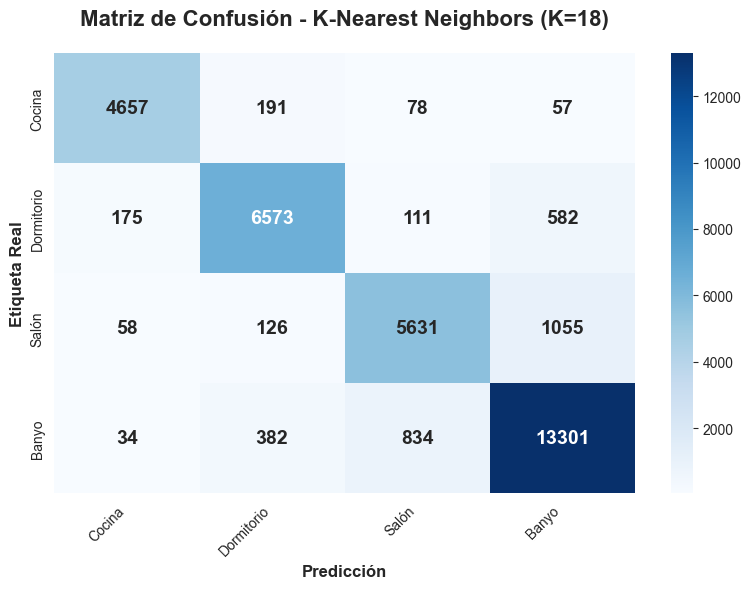

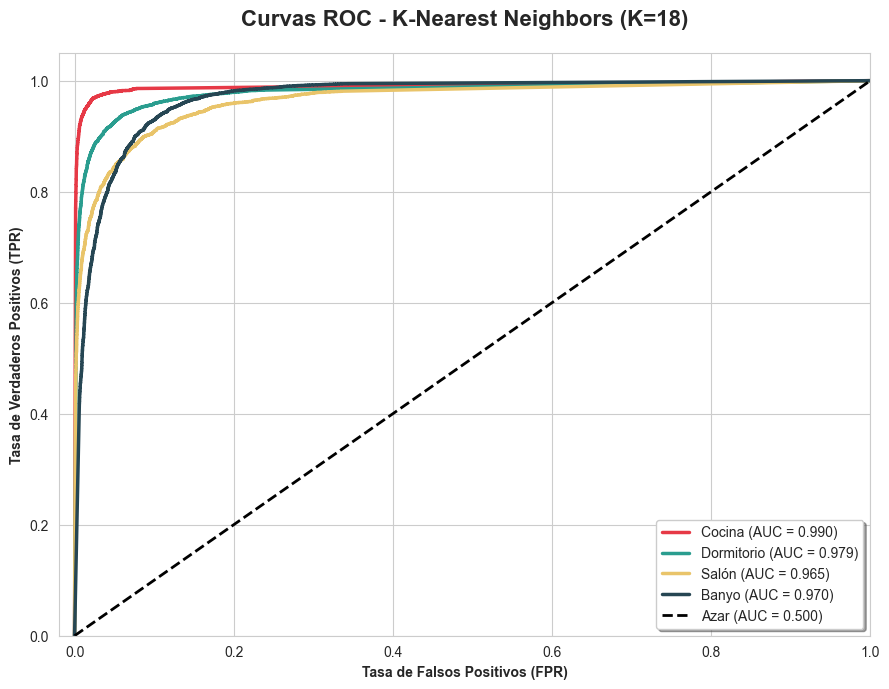

 Log Loss para K-Nearest Neighbors (K=18): 0.6736
 F1-Score (Macro) para K-Nearest Neighbors (K=18): 0.8917


0.8916848590320363

In [28]:
visualizar_matriz_confusion(y_test, y_pred_knn, "K-Nearest Neighbors (K=18)",clases)
visualizar_curva_roc(y_test, y_score_knn, "K-Nearest Neighbors (K=18)",clases)
evaluar_log_loss(y_test, y_score_knn, "K-Nearest Neighbors (K=18)")
evaluar_f1_score(y_test, y_pred_knn, "K-Nearest Neighbors (K=18)")

Evaluación SVC:

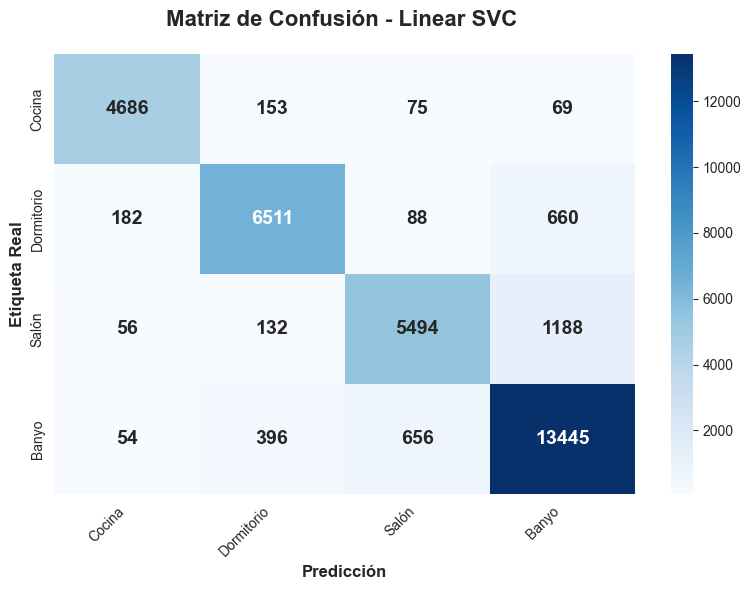

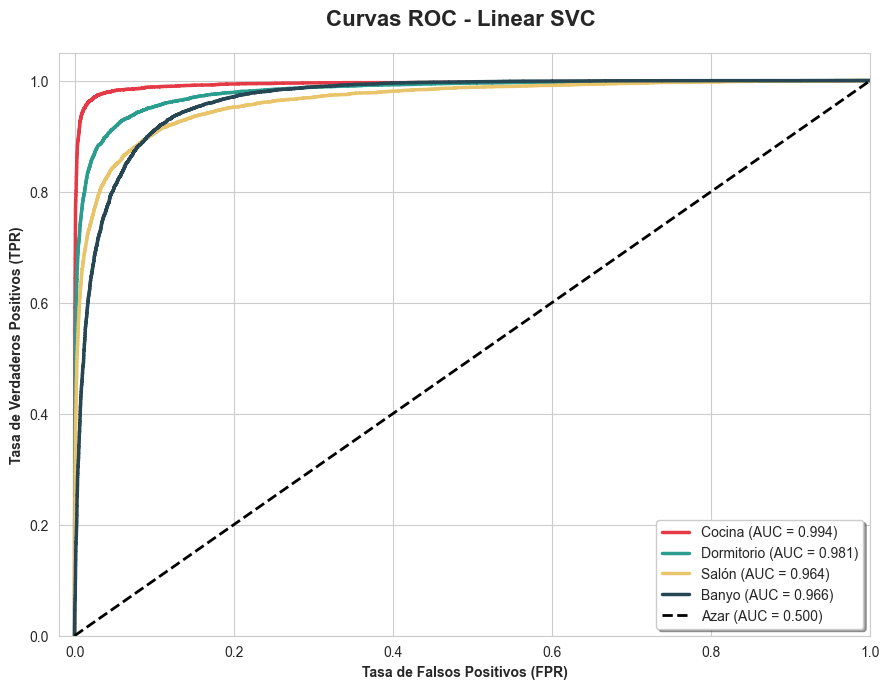

 Linear SVC  usa fronteras de decisión (distancias), no probabilidades. Log Loss no aplicable.
 F1-Score (Macro) para Linear SVC : 0.8908


0.8908034282811983

In [30]:
y_pred_svc, y_score_svc = obtener_predicciones(mejor_svc, X_test)

visualizar_matriz_confusion(y_test, y_pred_svc, "Linear SVC ",clases)
visualizar_curva_roc(y_test, y_score_svc, "Linear SVC ",clases)
evaluar_log_loss(y_test, y_score_svc, "Linear SVC ")
evaluar_f1_score(y_test, y_pred_svc, "Linear SVC ")

Evaluación MLP:

In [33]:
X_test_mlp,y_test_mlp = preparar_dataset_mlp(df)

y_pred_mlp, y_score_mlp = obtener_predicciones(mejor_mlp, X_test_mlp)

 Formato datos de test (Original): (50768, 2048)
 Formato datos de test (PCA - Listo para Keras): (50768, 512)


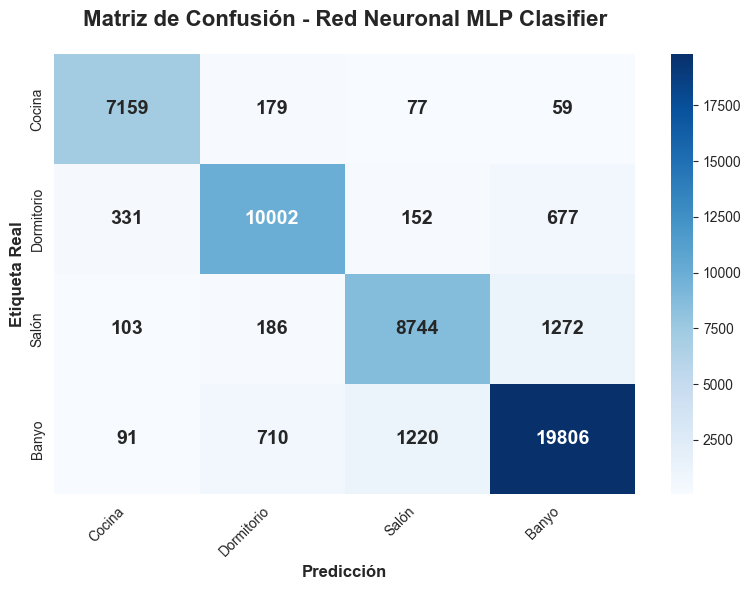

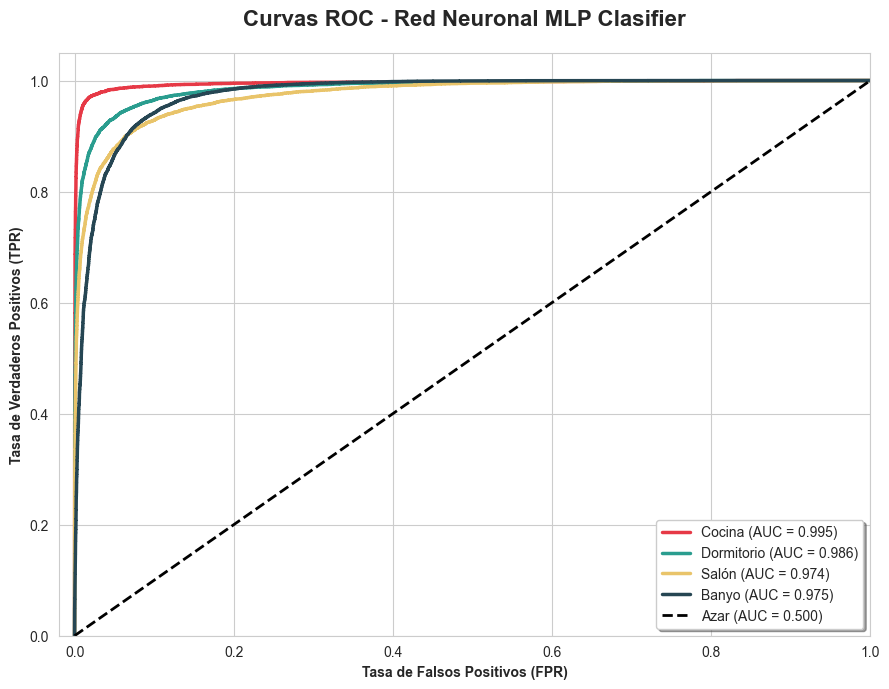

 Log Loss para Red Neuronal MLP Clasifier: 0.2896
 F1-Score (Macro) para Red Neuronal MLP Clasifier: 0.9012


0.9012298899156692

In [32]:

visualizar_matriz_confusion(y_test_mlp, y_pred_mlp, "Red Neuronal MLP Clasifier",clases)
visualizar_curva_roc(y_test_mlp, y_score_mlp, "Red Neuronal MLP Clasifier",clases)
evaluar_log_loss(y_test_mlp, y_score_mlp, "Red Neuronal MLP Clasifier")
evaluar_f1_score(y_test_mlp, y_pred_mlp, "Red Neuronal MLP Clasifier")

Evaluación SoftMax:

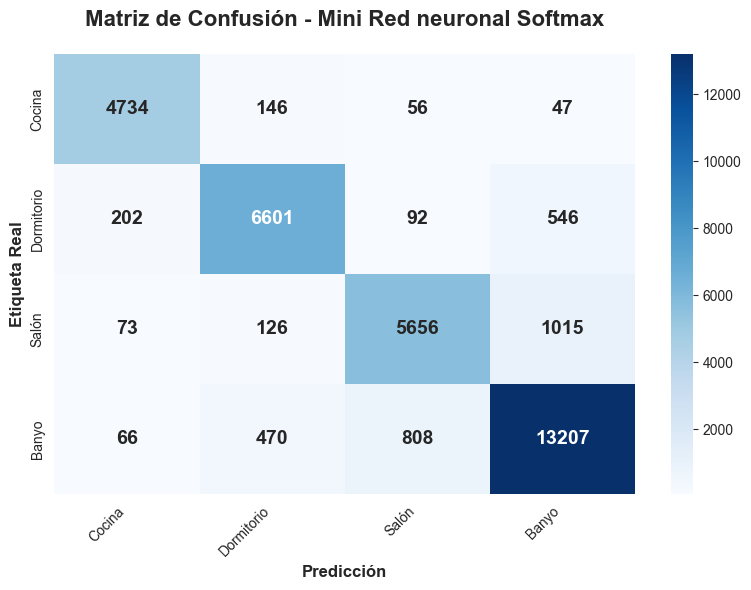

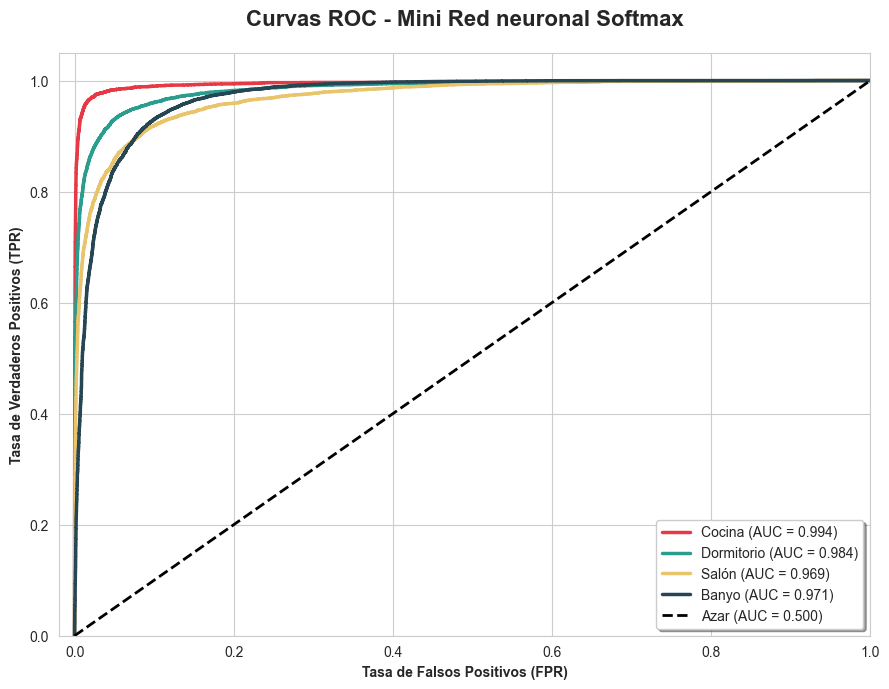

 Log Loss para Mini Red neuronal Softmax: 0.3007
 F1-Score (Macro) para Mini Red neuronal Softmax: 0.8932


0.8932132217662829

In [35]:
y_pred_sm, y_score_sm = obtener_predicciones(modelo_softmax, X_test)

visualizar_matriz_confusion(y_test, y_pred_sm, "Mini Red neuronal Softmax",clases)
visualizar_curva_roc(y_test, y_score_sm, "Mini Red neuronal Softmax",clases)
evaluar_log_loss(y_test, y_score_sm, "Mini Red neuronal Softmax")
evaluar_f1_score(y_test, y_pred_sm, "Mini Red neuronal Softmax")

# Nuestro mejor modelo de cnn obtenido:

Funciones útiles:

In [13]:
from PIL import Image,ImageOps
class SizeTransformer:
    def __init__(self, target_width=240,target_height = 160, color=(0, 0, 0)):
        self.target_size = (target_width, target_height)
        self.color = color

    def __call__(self, img):

        imagen_rgb = img.convert("RGB")
        imagen_final = ImageOps.pad(imagen_rgb, self.target_size, color=self.color)
        vector = np.array(imagen_final) / 255
        return vector

In [14]:
def cargador_datos(cliente, fase, clases, transformador):
    parquets = {clase: [] for clase in clases}
    archivos_base = {}
    
    for clase in clases:
        path = f"dataset_ml/dataset_vision/{fase}/{clase}"
        archivos_base[clase] = buscar_todos_los_archivos(cliente, path)
        parquets[clase] = archivos_base[clase].copy()

    while True:
        dfs_temporales = []
        
        for indice_num, clase in enumerate(clases):
            if len(parquets[clase]) == 0:
                parquets[clase] = archivos_base[clase].copy()
                random.shuffle(parquets[clase])
            
            archivo = parquets[clase].pop()
            
            path = f"dataset_ml/dataset_vision/{fase}/{clase}"
            df_chunk = bajar_minio(cliente, path, archivo)
            df_chunk['etiqueta_numerica'] = indice_num
            df_chunk['nombre_clase'] = clase
            
            dfs_temporales.append(df_chunk)
            
        df_mezclado = pd.concat(dfs_temporales).sample(frac=1).reset_index(drop=True)
        
        for _, fila in df_mezclado.iterrows():
            img = Image.open(io.BytesIO(fila['imagen_bytes']))
            tensor_listo = transformador(img)            
            
            if fase == "train":
                tensor_listo = aplicar_augmentation(tensor_listo)
            
            yield tensor_listo, fila['etiqueta_numerica']


In [15]:
clases = ["Cocina","Dormitorio","Salón","Banyo"]

mi_transformer = SizeTransformer()
BATCH_SIZE = 32
pasos_test = 315

dataset_test_imagenes = tf.data.Dataset.from_generator(
    lambda: cargador_datos(cliente, "test", clases, mi_transformer),
    output_signature=(
        tf.TensorSpec(shape=(160, 240, 3), dtype=tf.float32), 
        tf.TensorSpec(shape=(), dtype=tf.int32)             
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


Cargamos el modelo de wandb:

In [1]:
import wandb
import tensorflow as tf
api = wandb.Api()
wandb_run_path = "pd1-c2526-team2/CNN_imagenes/jm8fm8mb"
run_cnn = api.run(wandb_run_path)
nombre_archivo_cnn = "mejor_CNN_mejorada_C5.keras"
run_cnn.file(nombre_archivo_cnn).download(replace=True)
modelo_cnn = tf.keras.models.load_model(nombre_archivo_cnn)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\harra\_netrc.


Realizamos las preddicciones del dataset de test

In [16]:
from tqdm import tqdm
y_true_cnn = []
y_score_cnn = []

for lote_imagenes, lote_etiquetas in tqdm(dataset_test_imagenes.take(pasos_test), total=pasos_test, desc="Prediciendo"):
    probabilidades = modelo_cnn.predict(lote_imagenes, verbose=0) 
    
    y_score_cnn.extend(probabilidades)
    y_true_cnn.extend(lote_etiquetas.numpy())

y_score_cnn = np.array(y_score_cnn)
y_true_cnn = np.array(y_true_cnn)

Prediciendo: 100%|██████████| 315/315 [18:48<00:00,  3.58s/it]


Evaluamos el modelo:

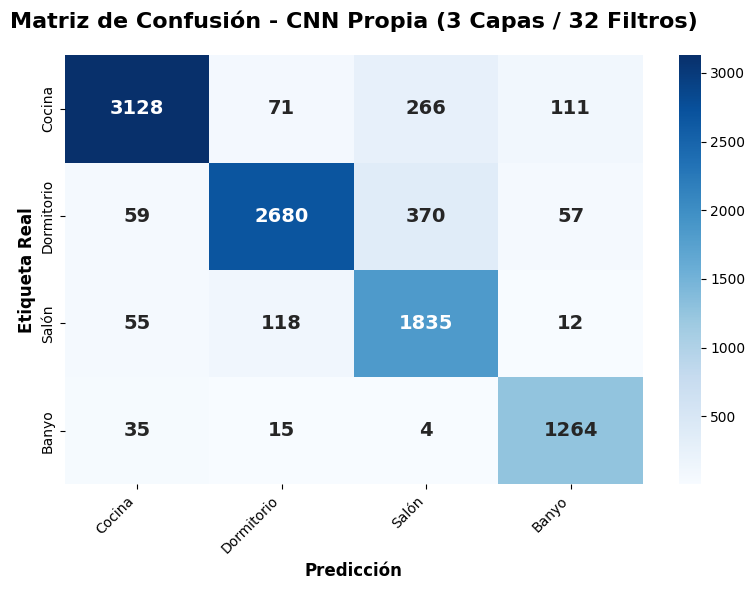

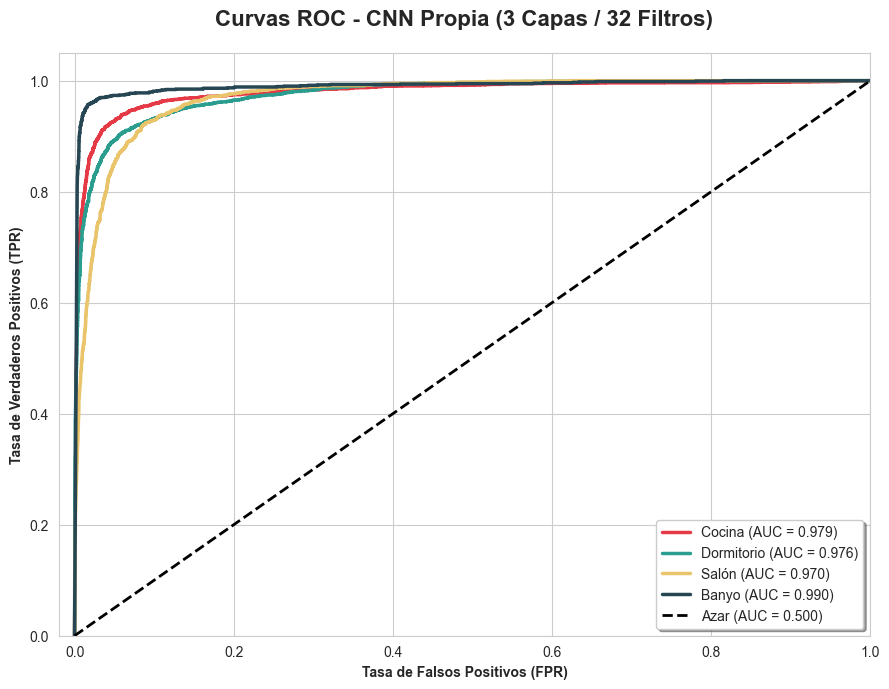

 Log Loss para CNN Propia (3 Capas / 32 Filtros): 0.6822
 F1-Score (Macro) para CNN Propia (3 Capas / 32 Filtros): 0.8826


0.8826442002570404

In [17]:
y_pred_cnn = np.argmax(y_score_cnn, axis=1)
visualizar_matriz_confusion(y_true_cnn, y_pred_cnn, "CNN Propia (3 Capas / 32 Filtros)", clases)
visualizar_curva_roc(y_true_cnn, y_score_cnn, "CNN Propia (3 Capas / 32 Filtros)", clases)
evaluar_log_loss(y_true_cnn, y_score_cnn, "CNN Propia (3 Capas / 32 Filtros)")
evaluar_f1_score(y_true_cnn, y_pred_cnn, "CNN Propia (3 Capas / 32 Filtros)")